In [ ]:
from scipy import stats
import pandas as pd
import numpy as np

In [ ]:
ctrp_thresholds_only_PC = pd.read_csv(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/data/ctrpv2_filtered_sensitivity_thresh.csv"
)
ctrp_thresholds_only_PC.head(2)

,cell ID,smiles,AAC,y,y_quartiles
0,CVCL_0186,B([C@H](CC(C)C)NC(=O)[C@H](Cc1ccccc1)NC(=O)c2c...,0.245250,interm,sensitive
1,CVCL_0026,B([C@H](CC(C)C)NC(=O)[C@H](Cc1ccccc1)NC(=O)c2c...,0.132198,resistant,interm


In [ ]:
gdsc = gdsc[
    gdsc["Cell line name"].isin(
        ["BxPC3", "CAPAN2", "CFPAC1", "HPAFII", "PANC1005", "SW1990"]
    )
]

In [ ]:
for cll in ctrp_thresholds_only_PC["cell ID"].unique():
    aux = ctrp_thresholds_only_PC[ctrp_thresholds_only_PC["cell ID"] == cll]
    print(cll, np.sum(aux["y_quartiles"] == "sensitive"))

CVCL_0186 103
CVCL_0026 106
CVCL_1119 103
CVCL_0313 100
CVCL_1639 98
CVCL_1723 106
CVCL_0042 85


In [ ]:
sum(ctrp_thresholds_only_PC["y_quartiles"] == "sensitive")

701

In [ ]:
ctrp_thresholds_only_PC[ctrp_thresholds_only_PC["y_quartiles"] == "sensitive"].smiles.nunique()

225

In [ ]:
gdsc.columns

Index(['ID', 'Drug Name', 'Targets', 'Z score', 'Count', 'Cell line name',
       'SMILES', 'cell ID', 'CPD'],
      dtype='object')

In [ ]:
sum(gdsc["Z score"] < -1)

14

In [ ]:
sum(gdsc["Z score"] > 1)

241

In [ ]:
Chem.MolToInchi(Chem.MolFromSmiles(ctrp_thresholds_only_PC["smiles"][2]))

NameError: name 'Chem' is not defined

In [ ]:
from rdkit import Chem
from rdkit.Chem import inchi
import pandas as pd


def smiles_to_inchi(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            inchi_string = Chem.MolToInchi(mol)
            # inchikey = inchi.InchiToInchi(inchi_string)
            # return inchikey
            return inchi_string
    except:
        return None
    return None


# Apply to both dataframes
ctrp_thresholds_only_PC["inchi"] = ctrp_thresholds_only_PC["smiles"].apply(
    smiles_to_inchi
)
gdsc["inchi"] = gdsc["SMILES"].apply(smiles_to_inchi)

# Find overlap
overlap = set(ctrp_thresholds_only_PC["inchi"]) & set(gdsc["inchi"])

# Calculate results
total_compounds = len(set(ctrp_thresholds_only_PC["inchi"]) | set(gdsc["inchi"]))
overlap_count = len(overlap)

print(f"Total unique compounds: {total_compounds}")
print(f"Overlapping compounds: {overlap_count}")
print(f"Overlap percentage: {overlap_count / total_compounds * 100:.2f}%")

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefined stereo

[18:11:26] WARNING: Omitted undefi

Total unique compounds: 583
Overlapping compounds: 38
Overlap percentage: 6.52%


[18:11:28] WARNING: Omitted undefined stereo

[18:11:28] WARNING: Omitted undefined stereo

[18:11:28] WARNING: Omitted undefined stereo

[18:11:28] WARNING: Omitted undefined stereo

[18:11:28] WARNING: Omitted undefined stereo

[18:11:28] WARNING: Omitted undefined stereo

[18:11:28] WARNING: Charges were rearranged

[18:11:28] WARNING: Proton(s) added/removed

[18:11:28] WARNING: Charges were rearranged

[18:11:28] WARNING: Omitted undefined stereo

[18:11:28] WARNING: Charges were rearranged

[18:11:28] WARNING: Charges were rearranged

[18:11:28] WARNING: Omitted undefined stereo

[18:11:28] WARNING: Omitted undefined stereo



In [ ]:
actives_ctrp_total = ctrp_thresholds_only_PC[ctrp_thresholds_only_PC['y_quartiles']=='sensitive'].inchi.values
actives_gdsc_total = gdsc[gdsc['Z score']<-1].inchi.values
print('Total actives:' ,len(set(actives_ctrp_total).union(set(actives_gdsc_total))))

Total actives: 237


In [ ]:
ctrp_thresholds_only_PC.head(2)

,cell ID,smiles,AAC,y,y_quartiles,inchi
0,CVCL_0186,B([C@H](CC(C)C)NC(=O)[C@H](Cc1ccccc1)NC(=O)c2c...,0.245250,interm,sensitive,InChI=1S/C19H25BN4O4/c1-13(2)10-17(20(27)28)24...
1,CVCL_0026,B([C@H](CC(C)C)NC(=O)[C@H](Cc1ccccc1)NC(=O)c2c...,0.132198,resistant,interm,InChI=1S/C19H25BN4O4/c1-13(2)10-17(20(27)28)24...


In [ ]:
ctrp_thresholds_only_PC["cell ID"].unique()

array(['CVCL_0186', 'CVCL_0026', 'CVCL_1119', 'CVCL_0313', 'CVCL_1639',
       'CVCL_1723', 'CVCL_0042'], dtype=object)

In [ ]:
cell2name = {
    "CVCL_0186": "BxPC3",
    "CVCL_0026": "CAPAN2",
    "CVCL_1119": "CFPAC1",
    "CVCL_0313": "HPAFII",
    "CVCL_1639": "PANC1005",
    "CVCL_1723": "SW1990",
}

In [ ]:
ctrp_thresholds_only_PC["cell name"] = ctrp_thresholds_only_PC["cell ID"].map(cell2name)

In [ ]:
gdsc["Cell line name"].unique()

array(['BxPC3', 'CAPAN2', 'CFPAC1', 'HPAFII', 'PANC1005', 'SW1990'],
      dtype=object)

In [ ]:
gdsc.columns

Index(['ID', 'Drug Name', 'Targets', 'Z score', 'Count', 'Cell line name',
       'SMILES', 'cell ID', 'CPD', 'inchi'],
      dtype='object')

In [ ]:
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

-0.18887652947719688 0.3175063206648826
-0.23397683397683397 0.16960672488860354
-0.16618464961067853 0.38011770642295883
-0.3266009852216748 0.08377047144718365
-0.494881588999236 0.002925703705953655
0.09195402298850575 0.6416600274082447


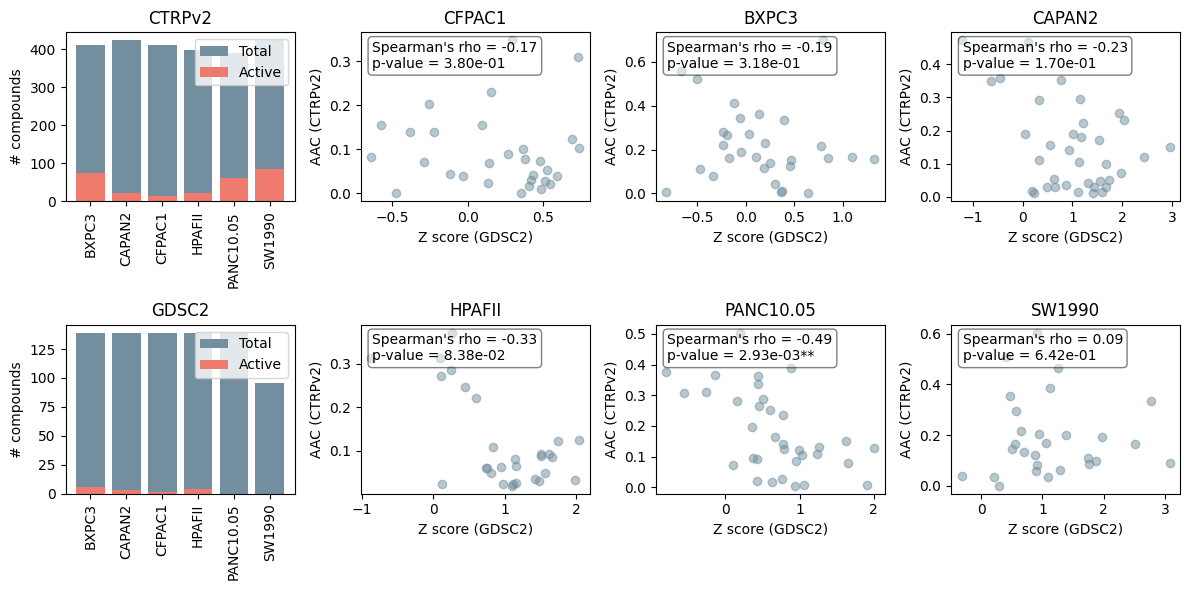

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

cll_lines_name_dict = {
    "BxPC3": "BXPC3",
    "CAPAN2": "CAPAN2",
    "CFPAC1": "CFPAC1",
    "HPAFII": "HPAFII",
    "PANC1005": "PANC10.05",
    "SW1990": "SW1990",
}
# Set a beautiful color palette
colors = sns.color_palette("deep", 2)
colors = ["#738f9fff", "#ee7b6dff"]

# Prepare the data (assuming previous data preparation code remains the same)
gdsc_bars = []
gdsc_sens = []
ctrp_bars = []
ctrp_sens = []

clls = ctrp_thresholds_only_PC["cell name"].dropna().unique()
cll_names = [cll_lines_name_dict[c] for c in clls]
for cll in clls:
    aux1 = ctrp_thresholds_only_PC[ctrp_thresholds_only_PC["cell name"] == cll]
    aux2 = gdsc[gdsc["Cell line name"] == cll]
    ctrp_bars.append(len(aux1["inchi"].unique()))
    ctrp_sens.append(aux1[aux1["y"] == "sensitive"]["inchi"].nunique())
    gdsc_bars.append(len(aux2["inchi"].unique()))
    gdsc_sens.append(aux2[aux2["Z score"] < -1]["inchi"].nunique())

# Create a 2x4 grid of subplots
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
x = np.arange(0, 6, 1)

# Flatten the axs array for easier indexing
axs_flat = axs.flatten()

# CTRP Bar Plots
axs_flat[0].bar(x, ctrp_bars, color=colors[0], label="Total")
axs_flat[0].bar(x, ctrp_sens, color=colors[1], label="Active")
axs_flat[0].set_title("CTRPv2")
axs_flat[0].set_xticks(x)
axs_flat[0].set_xticklabels(cll_names, rotation=90)
axs_flat[0].set_ylabel("# compounds")
axs_flat[0].legend()

# GDSC Bar Plots
axs_flat[4].bar(x, gdsc_bars, color=colors[0], label="Total")
axs_flat[4].bar(x, gdsc_sens, color=colors[1], label="Active")
axs_flat[4].set_title("GDSC2")
axs_flat[4].set_xticks(x)
axs_flat[4].set_xticklabels(cll_names, rotation=90)
axs_flat[4].set_ylabel("# compounds")
axs_flat[4].legend()

# Scatter plots for correlation
common_inchis = set(ctrp_thresholds_only_PC["inchi"]) & set(gdsc["inchi"])
ctrp_filtered = ctrp_thresholds_only_PC[
    ctrp_thresholds_only_PC["inchi"].isin(common_inchis)
]
gdsc_filtered = gdsc[gdsc["inchi"].isin(common_inchis)]

# Create scatter plots for each cell line
for idx, cll in enumerate(clls, start=2):
    aux1 = ctrp_filtered[ctrp_filtered["cell name"] == cll]
    aux2 = gdsc_filtered[gdsc_filtered["Cell line name"] == cll]
    merged_df = pd.merge(aux1, aux2, on="inchi", how="inner")
    if idx == 4:
        idx = 1

    if len(merged_df) > 1:
        cll = cll_lines_name_dict[cll]
        # Calculate correlations
        correlation, p_value = stats.pearsonr(merged_df["Z score"], merged_df["AAC"])
        spearman_corr, spearman_p = stats.spearmanr(
            merged_df["Z score"], merged_df["AAC"]
        )
        print(spearman_corr, spearman_p)
        # Scatter plot
        axs_flat[idx].scatter(
            merged_df["Z score"], merged_df["AAC"], alpha=0.5, color=colors[0]
        )
        axs_flat[idx].set_xlabel("Z score (GDSC2)")
        axs_flat[idx].set_ylabel("AAC (CTRPv2)")
        axs_flat[idx].set_title(f"{cll}")

        # Add correlation text
        stars = significance_stars(spearman_p)
        textstr = f"Spearman's rho = {spearman_corr:.2f}\np-value = {spearman_p:.2e}{stars}"
        props = dict(boxstyle="round", facecolor="white", alpha=0.5)
        axs_flat[idx].text(
            0.05,
            0.95,
            textstr,
            transform=axs_flat[idx].transAxes,
            verticalalignment="top",
            bbox=props,
        )

# Adjust layout and display
plt.tight_layout()

plt.savefig(
  "supplementary_GDSC_vs_CTRP.svg",
  format="svg",
  dpi=300,
  bbox_inches="tight",
)

plt.show()
plt.close()

# Panel b

In [ ]:
aucs = pd.read_csv(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/Marta_collab/select_compounds_with_specific_effects_databases/databases_vs_MTT_AUC.csv"
)
ec50 = pd.read_csv(
    "/aloy/home/grojas/tesis/cell_line_specific_NCEs/Marta_collab/select_compounds_with_specific_effects_databases/databases_vs_MTT_EC50.csv"
)

In [ ]:
aucs

,compound,SMILES,BXPC3_DC,CAPAN2_DC,CFPAC1_DC,HPAFII_DC,PANC10.05_DC,SW1990_DC,BXPC3,CAPAN2,CFPAC1,HPAFII,PANC10.05,SW1990
0,STF-31,CC(C)(C)c1ccc(S(=O)(=O)NCc2ccc(C(=O)Nc3cccnc3)...,0.76,0.970,0.78,0.84,0.78,0.73,498.5,614.1,556.3,595.4,527.0,541.5
1,Tosedostat,CC(C)C[C@@H](C(=O)N[C@H](C(=O)OC1CCCC1)c1ccccc...,0.53,0.830,0.84,0.91,0.87,0.85,553.1,690.6,614.2,748.7,855.7,659.3
2,AR-42,CC(C)[C@H](C(=O)Nc1ccc(C(=O)NO)cc1)c1ccccc1,0.64,0.950,0.89,0.80,0.56,0.92,609.2,608.2,634.8,680.2,623.3,638.1
3,Simvastatin,CCC(C)(C)C(=O)O[C@H]1C[C@@H](C)C=C2C=C[C@H](C)...,0.81,0.950,0.99,0.86,1.02,0.66,616.5,704.5,605.1,747.8,674.7,607.9
4,Ki-8751,COc1cc2nccc(Oc3ccc(NC(=O)Nc4ccc(F)cc4F)c(F)c3)...,0.97,1.060,0.98,0.99,0.58,0.94,582.4,628.1,589.4,657.9,638.5,606.8
5,Ceranib-2,COc1ccc(/C=C/C(=O)c2c(-c3ccccc3)c3ccccc3[nH]c2...,0.60,0.870,0.89,0.88,0.85,0.88,526.2,587.2,483.8,679.9,557.8,635.7
6,FMK,Cc1ccc(-c2c(C(=O)CF)n(CCCO)c3ncnc(N)c23)cc1,0.97,1.010,0.75,0.89,0.82,1.06,593.3,638.4,626.6,685.8,599.9,609.4
7,Selumetinib,Cn1cnc2c(F)c(Nc3ccc(Br)cc3Cl)c(C(=O)NOCCO)cc21,0.48,0.650,1.02,0.67,0.72,0.67,549.1,511.8,728.2,644.4,547.6,581.4
8,Gemcitabine,Nc1ccn([C@@H]2O[C@H](CO)[C@@H](O)C2(F)F)c(=O)n1,0.47,0.890,0.38,0.73,0.51,0.58,523.7,620.8,508.5,672.8,812.8,480.2
9,AS-605240,O=C1NC(=O)/C(=C/c2ccc3nccnc3c2)S1,0.92,0.890,0.88,0.53,0.64,0.89,591.1,594.9,607.5,633.5,670.4,655.2


In [ ]:
cdict = {"sensitive": "#ee7b6dff", "resistant": "#556b9fff", "neutral": "#b8c6ceff"}
colors2 = [
    ["neutral", "resistant", "neutral", "neutral", "neutral", "sensitive"],
    ["sensitive", "neutral", "neutral", "resistant", "neutral", "neutral"],
    ["sensitive", "resistant", "neutral", "neutral", "sensitive", "resistant"],
    ["resistant", "resistant", "resistant", "neutral", "resistant", "sensitive"],
    ["resistant", "resistant", "resistant", "resistant", "sensitive", "resistant"],
    ["sensitive", "resistant", "neutral", "neutral", "neutral", "neutral"],
    ["resistant", "resistant", "sensitive", "neutral", "neutral", "resistant"],
    ["sensitive", "sensitive", "resistant", "sensitive", "sensitive", "sensitive"],
    ["sensitive", "resistant", "sensitive", "sensitive", "sensitive", "sensitive"],
    ["resistant", "resistant", "neutral", "sensitive", "sensitive", "neutral"],
    ["sensitive", "sensitive", "resistant", "resistant", "sensitive", "sensitive"],
    ["resistant", "sensitive", "neutral", "resistant", "sensitive", "neutral"],
]

colors2 = [[cdict[c] for c in row] for row in colors2]
colors2

[['#b8c6ceff',
  '#556b9fff',
  '#b8c6ceff',
  '#b8c6ceff',
  '#b8c6ceff',
  '#ee7b6dff'],
 ['#ee7b6dff',
  '#b8c6ceff',
  '#b8c6ceff',
  '#556b9fff',
  '#b8c6ceff',
  '#b8c6ceff'],
 ['#ee7b6dff',
  '#556b9fff',
  '#b8c6ceff',
  '#b8c6ceff',
  '#ee7b6dff',
  '#556b9fff'],
 ['#556b9fff',
  '#556b9fff',
  '#556b9fff',
  '#b8c6ceff',
  '#556b9fff',
  '#ee7b6dff'],
 ['#556b9fff',
  '#556b9fff',
  '#556b9fff',
  '#556b9fff',
  '#ee7b6dff',
  '#556b9fff'],
 ['#ee7b6dff',
  '#556b9fff',
  '#b8c6ceff',
  '#b8c6ceff',
  '#b8c6ceff',
  '#b8c6ceff'],
 ['#556b9fff',
  '#556b9fff',
  '#ee7b6dff',
  '#b8c6ceff',
  '#b8c6ceff',
  '#556b9fff'],
 ['#ee7b6dff',
  '#ee7b6dff',
  '#556b9fff',
  '#ee7b6dff',
  '#ee7b6dff',
  '#ee7b6dff'],
 ['#ee7b6dff',
  '#556b9fff',
  '#ee7b6dff',
  '#ee7b6dff',
  '#ee7b6dff',
  '#ee7b6dff'],
 ['#556b9fff',
  '#556b9fff',
  '#b8c6ceff',
  '#ee7b6dff',
  '#ee7b6dff',
  '#b8c6ceff'],
 ['#ee7b6dff',
  '#ee7b6dff',
  '#556b9fff',
  '#556b9fff',
  '#ee7b6dff',
  '#ee7b6dff'],

In [ ]:
aucs_full_dc = []
aucs_full_mtt = []
for idx, c in enumerate(
    ["BXPC3", "CAPAN2", "CFPAC1", "HPAFII", "PANC10.05", "SW1990"], start=2
):
    drugcell = aucs[c + "_DC"].values
    mtt = aucs[c].values

    aucs_full_dc.append(drugcell)
    aucs_full_mtt.append(mtt)

# All together
aucs_full_mtt = np.array(aucs_full_mtt).flatten()
aucs_full_dc = np.array(aucs_full_dc).flatten()


0.8272776117646036 0.04217311957183859
0.6924263564048205 0.12735384821909337
0.14879895454599434 0.7784488565954666
0.298947036175498 0.5649377939664846
-0.25758198130215787 0.6221721141395737
0.35139067773754035 0.49460803711463613
-0.10655447288996137 0.8407731927193685
0.7824125446494105 0.06586568812876155
0.24546024258717117 0.6392042156049711
-0.5549507997883983 0.25302800748977505
0.666526811847343 0.14826471338892075
0.47755545401720706 0.3381222791581156


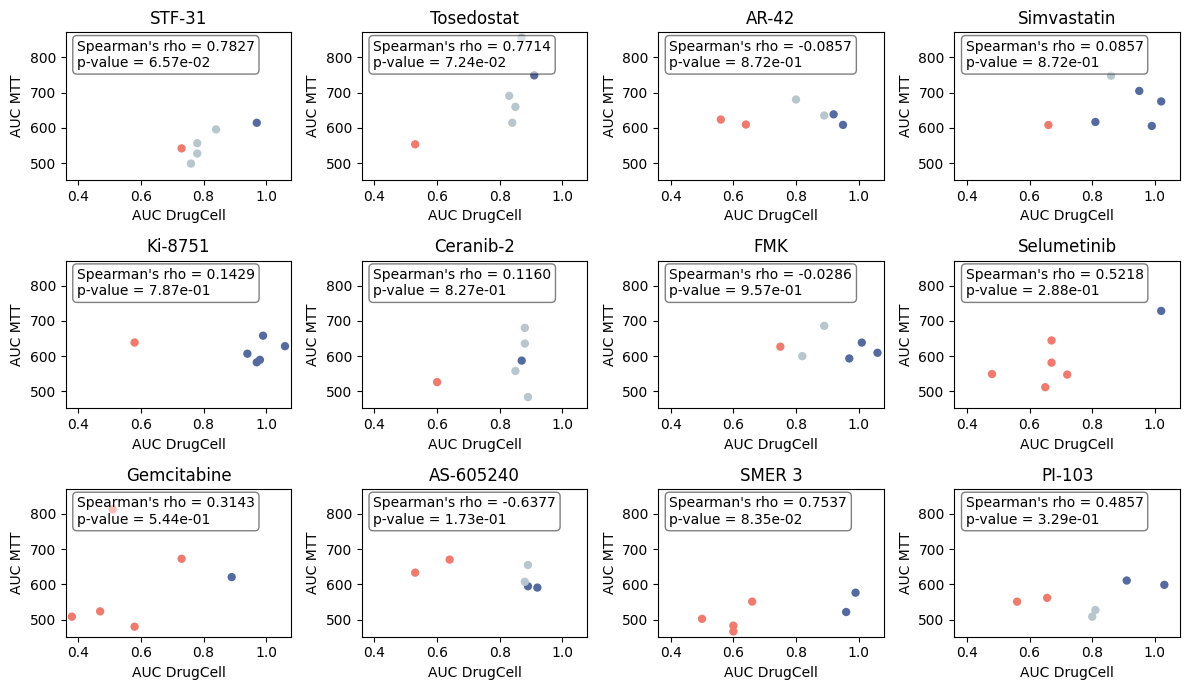

In [ ]:
fig, axs = plt.subplots(3, 4, figsize=(12, 7))
axs_flat = axs.flatten()

max_auc_dc = np.max(np.array(aucs_full_dc).flatten()) + 0.02
min_auc_dc = np.min(np.array(aucs_full_dc).flatten()) - 0.02
max_auc_mtt = np.max(np.array(aucs_full_mtt).flatten()) + 15
min_auc_mtt = np.min(np.array(aucs_full_mtt).flatten()) - 15

cpds = aucs["compound"].values
for i in range(len(aucs)):
    drugcell = aucs.filter(like="DC").iloc[i].values
    mtt = aucs[aucs.columns[~aucs.columns.str.endswith("_DC")]].iloc[i, 2:].values

    idx = i

    # Calculate correlations
    correlation, p_value = stats.pearsonr(drugcell, mtt)
    spearman_corr, spearman_p = stats.spearmanr(drugcell, mtt)

    # Scatter plot
    axs_flat[idx].scatter(drugcell, mtt, alpha=1, color=colors2[i], lw=0)
    axs_flat[idx].set_xlabel("AUC DrugCell")
    axs_flat[idx].set_ylabel("AUC MTT")
    axs_flat[idx].set_title(cpds[i])
    axs_flat[idx].set_xlim([min_auc_dc, max_auc_dc])
    axs_flat[idx].set_ylim([min_auc_mtt, max_auc_mtt])

    # Add correlation text
    stars = significance_stars(spearman_p)
    textstr = f"Spearman's rho = {spearman_corr:.4f}\np-value = {spearman_p:.2e}{stars}"
    props = dict(boxstyle="round", facecolor="white", alpha=0.5)
    axs_flat[idx].text(
        0.05,
        0.95,
        textstr,
        transform=axs_flat[idx].transAxes,
        verticalalignment="top",
        bbox=props,
    )

    print(correlation, p_value)

plt.tight_layout()